--- Running Simon's Algorithm for secret '01101' ---
Successfully collected 16 unique bitstrings.
Solved Secret String: 01101


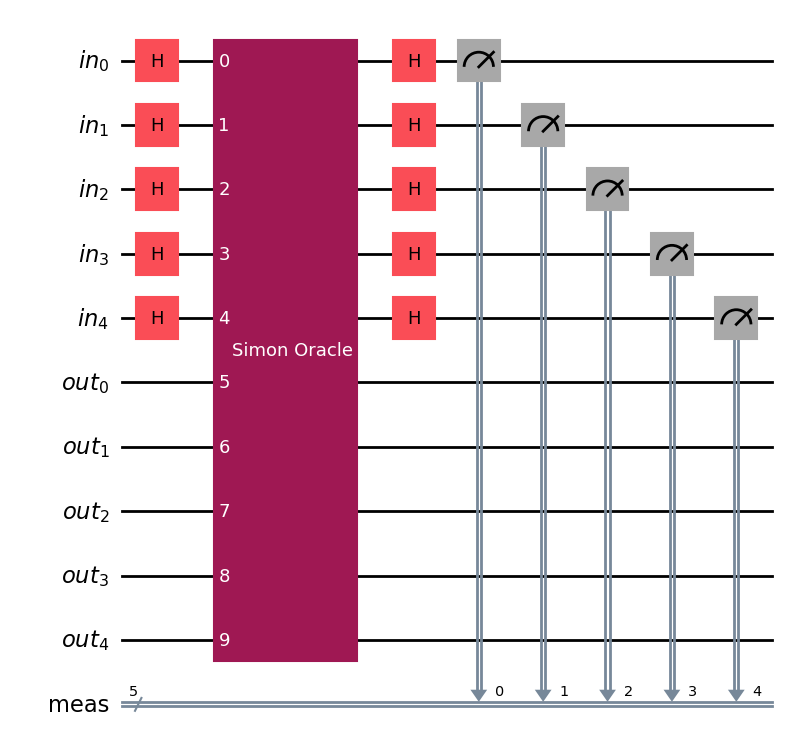

In [1]:
# ==========================================
# CHALLENGE: Generalised Simon's Wrapper
# ==========================================
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

def create_simon_oracle(secret):
    n = len(secret)
    qr_in = QuantumRegister(n, 'in')
    qr_out = QuantumRegister(n, 'out')
    qc = QuantumCircuit(qr_in, qr_out, name="Simon Oracle")
    for i in range(n):
        qc.cx(qr_in[i], qr_out[i])
    s_rev = secret[::-1]
    m = s_rev.find('1') 
    if m != -1:
        for j in range(n):
            if s_rev[j] == '1':
                qc.cx(qr_in[m], qr_out[j])
    return qc

def build_simons_circuit(secret):
    n = len(secret)
    qr_in = QuantumRegister(n, 'in')
    qr_out = QuantumRegister(n, 'out')
    cr = ClassicalRegister(n, 'meas')
    qc = QuantumCircuit(qr_in, qr_out, cr)
    qc.h(qr_in)
    qc.append(create_simon_oracle(secret), range(2*n))
    qc.h(qr_in)
    qc.measure(qr_in, cr)
    return qc

def rref_gf2(matrix):
    M = np.array(matrix, dtype=int)
    rows, cols = M.shape
    r = 0
    for c in range(cols):
        pivot = None
        for i in range(r, rows):
            if M[i, c] == 1:
                pivot = i
                break
        if pivot is not None:
            M[[r, pivot]] = M[[pivot, r]] 
            for i in range(rows):
                if i != r and M[i, c] == 1:
                    M[i] = (M[i] + M[r]) % 2 
            r += 1
    return M

def solve_simons_equations(measurements, n):
    if not measurements:
        return '0' * n
    matrix = [[int(bit) for bit in y] for y in measurements if y != '0'*n]
    M = rref_gf2(matrix)
    for i in range(1, 2**n):
        s = [int(b) for b in format(i, f'0{n}b')]
        if all(np.dot(M, s) % 2 == 0):
            return format(i, f'0{n}b')
    return '0' * n

def run_simons_algorithm(secret_string):
    """
    Accepts any secret bitstring, runs Simon's quantum algorithm, 
    and automatically determines the string.
    """
    n = len(secret_string)
    print(f"--- Running Simon's Algorithm for secret '{secret_string}' ---")
    
    if secret_string == '0' * n:
        print("Note: Secret is all-zeros. The oracle function is a 1-to-1 mapping.")
        
    qc = build_simons_circuit(secret_string)
    simulator = AerSimulator()
    compiled = transpile(qc, simulator)
    
    counts = simulator.run(compiled, shots=2048).result().get_counts()
    measurements = list(counts.keys())
    
    solved_string = solve_simons_equations(measurements, n)
    
    print(f"Successfully collected {len(measurements)} unique bitstrings.")
    print(f"Solved Secret String: {solved_string}")
    
    return solved_string, qc

# Test the generalised function with a 5-bit string
final_secret, final_qc = run_simons_algorithm('01101')

# Draw the circuit (displays in notebook)
final_qc.draw('mpl', style='iqp')